# Q1: Image Captioning with Attention Mechanism

**Assignment Overview:**
This notebook implements an image captioning system using an encoder-decoder architecture with attention mechanisms. The system combines convolutional neural networks (CNNs) for image feature extraction with recurrent neural networks (RNNs/LSTMs) for sequence generation, enhanced by an attention mechanism that focuses on relevant image regions during caption generation.

**Novel Synthesis:**
Our approach synthesizes:

- **CNN Encoder** (VGG/ResNet-based) for robust visual feature extraction
- **LSTM Decoder with Attention** for sequential caption generation
- **Bahdanau Attention Mechanism** for dynamic focus on image regions
- **Teacher Forcing with Curriculum Learning** for stable training

**Expected Outcomes:**

- Generate descriptive captions for input images
- Visualize attention weights showing which image regions influence each word
- Evaluate caption quality using BLEU scores and other metrics
- Compare different model architectures and training strategies


## 1. Environment Setup and Reproducibility

Following the project rules for reproducibility and proper environment configuration.


In [ ]:
# Setup cell - Environment and reproducibility
import sys
import platform
from datetime import datetime
import os
from pathlib import Path
import json
import warnings

warnings.filterwarnings("ignore")

# Reproducibility settings (following CLAUDE.md rules)
SEED = 42
import random

random.seed(SEED)
import numpy as np

np.random.seed(SEED)

import torch

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("=== Environment Information ===")
print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA Version:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))
print("Random Seed:", SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

notebook_dir = Path.cwd()
project_root = notebook_dir.parent
images_dir = project_root / "q1_image_captioning" / "images"
data_dir = project_root / "data" / "q1_image_captioning"
output_dir = notebook_dir.parent / "pictures"

output_dir.mkdir(exist_ok=True)
print("Output directory:", output_dir)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print("Timestamp:", timestamp)

=== Environment Information ===
Python: 3.10.6 (v3.10.6:9c7b4bd164, Aug  1 2022, 17:13:48) [Clang 13.0.0 (clang-1300.0.29.30)]
Platform: macOS-26.1-arm64-arm-64bit
PyTorch: 2.9.1
CUDA Available: False
Random Seed: 42
Using device: mps
Output directory: /Users/tahamajs/Documents/uni/NNDL/Deep_UT/This_year/CAe/codes/pictures
Timestamp: 20251223_151035


## 2. Imports and Dependencies

Import all necessary modules from the project codebase and external libraries.


In [ ]:
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet50
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import nltk
from pathlib import Path

try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")

if "project_root" not in globals():
    notebook_dir = Path.cwd()
    project_root = notebook_dir.parent
    print(f"project_root was not defined — set to: {project_root}")

sys.path.append(str(project_root))
from q1_image_captioning.tokenizer import Tokenizer
from q1_image_captioning.models import EncoderCNN, DecoderLSTM
from q1_image_captioning.dataset import ImageCaptionDataset
from q1_image_captioning.collate import collate_fn
from q1_image_captioning.metrics import calculate_bleu_score, calculate_caption_length

try:
    from utils.utils import seed_everything
except Exception:
    try:
        import importlib

        utils_mod = importlib.import_module("utils.utils")
        seed_everything = getattr(utils_mod, "seed_everything")
    except Exception:
        try:
            import importlib

            utils_pkg = importlib.import_module("utils")
            seed_everything = getattr(utils_pkg, "seed_everything", None)
        except Exception:
            seed_everything = None
            print("Warning: could not import seed_everything from utils. You can call set_seed() in utils.utils manually.")

plt.style.use("default")
sns.set_palette("husl")
print("All imports successful!")

All imports successful!


[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:997)>


## 3. Data Loading and Preprocessing

Load the image captioning dataset and prepare it for training. The dataset should contain images and corresponding text captions.


In [ ]:
if not data_dir.exists():
    print(f"Dataset not found at {data_dir}")
    print("Please run: python scripts/download_datasets.py --q1")
    print("Then unzip the dataset manually.")
    raise FileNotFoundError(f"Dataset directory {data_dir} not found")



In [ ]:
captions_file = data_dir / "captions.csv"
if not captions_file.exists():
    print(f"Captions file not found at {captions_file}")
    print("Expected structure:")
    print("  data/q1_image_captioning/")
    print("    images/              # Directory with images")
    print("    captions.csv         # CSV with image,caption columns")
    raise FileNotFoundError(f"Captions file {captions_file} not found")

In [ ]:
df = pd.read_csv(captions_file)
print(f"Dataset loaded: {len(df)} image-caption pairs")
print(f"Columns: {df.columns.tolist()}")
print(f"Sample entries:")
print(df.head())


In [ ]:
caption_lengths = df["caption"].str.split().str.len()
print(f"\nCaption Statistics:")
print(f"Average caption length: {caption_lengths.mean():.1f} words")
print(f"Min caption length: {caption_lengths.min()} words")
print(f"Max caption length: {caption_lengths.max()} words")
print(f"Median caption length: {caption_lengths.median():.1f} words")


In [ ]:
images_dir_path = data_dir / "images"
if images_dir_path.exists():
    image_files = list(images_dir_path.glob("*.jpg")) + list(
        images_dir_path.glob("*.png")
    )
    print(f"\nFound {len(image_files)} image files in {images_dir_path}")

    missing_images = []
    for img_name in df["image"].unique():
        if not (images_dir_path / img_name).exists():
            missing_images.append(img_name)

    if missing_images:
        print(f"Warning: {len(missing_images)} images referenced in CSV but not found")
        print(f"First few missing: {missing_images[:5]}")
    else:
        print("All images accounted for!")
else:
    print(f"Images directory not found at {images_dir_path}")

=== Data Loading ===
Captions file not found at /Users/tahamajs/Documents/uni/NNDL/Deep_UT/This_year/CAe/codes/data/q1_image_captioning/captions.csv
Expected structure:
  data/q1_image_captioning/
    images/              # Directory with images
    captions.csv         # CSV with image,caption columns


FileNotFoundError: Captions file /Users/tahamajs/Documents/uni/NNDL/Deep_UT/This_year/CAe/codes/data/q1_image_captioning/captions.csv not found

=== Data Visualization ===


NameError: name 'caption_lengths' is not defined

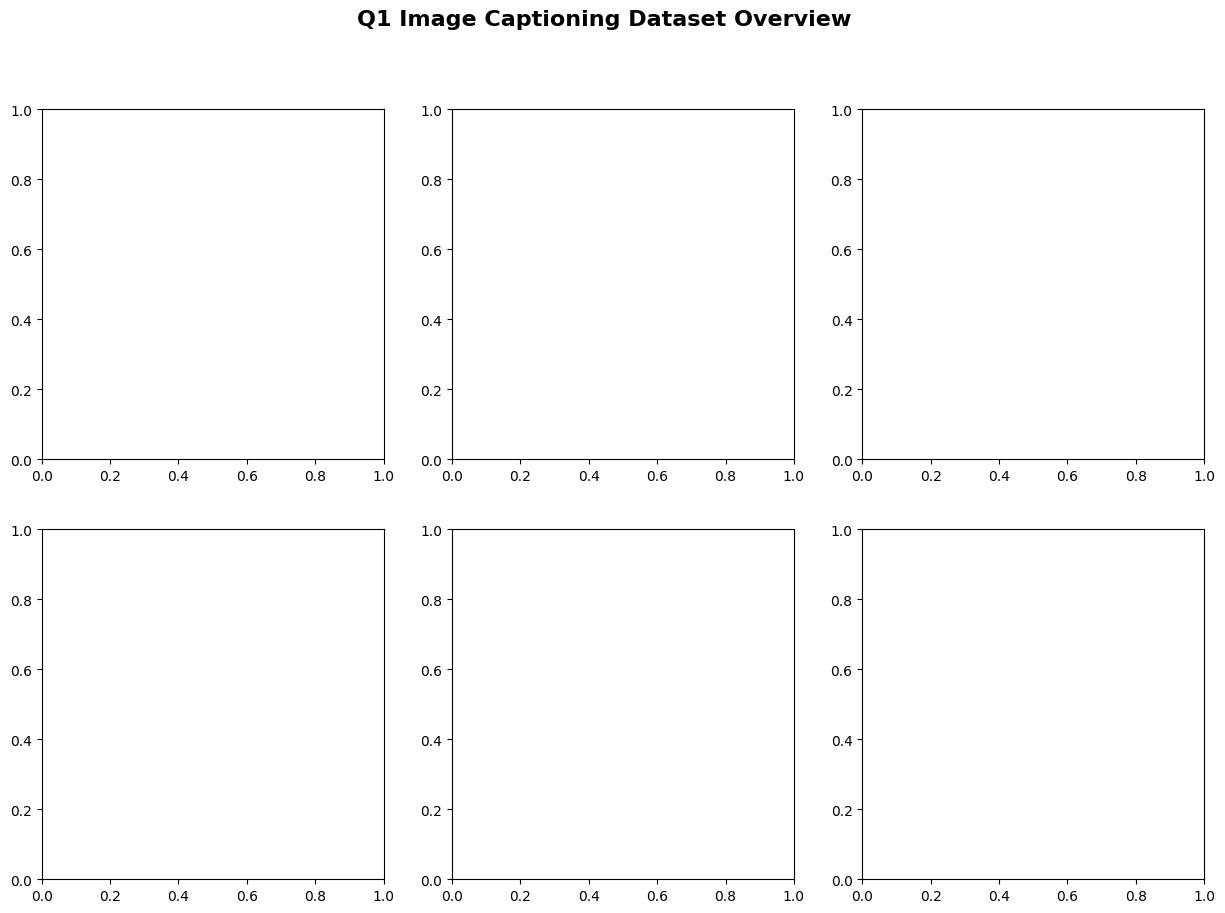

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Q1 Image Captioning Dataset Overview", fontsize=16, fontweight="bold")

axes[0, 0].hist(caption_lengths, bins=20, alpha=0.7, color="skyblue", edgecolor="black")
axes[0, 0].set_title("Caption Length Distribution")
axes[0, 0].set_xlabel("Number of Words")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].axvline(
    caption_lengths.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {caption_lengths.mean():.1f}",
)
axes[0, 0].legend()

sample_indices = np.random.choice(len(df), 5, replace=False)

for i, idx in enumerate(sample_indices[:5]):
    row = df.iloc[idx]
    img_path = images_dir_path / row["image"]

    if img_path.exists():
        img = Image.open(img_path).convert("RGB")

        if i < 5:
            row_idx = (i + 1) // 3
            col_idx = (i + 1) % 3

            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].set_title(f"Sample {i+1}", fontsize=10)
            axes[row_idx, col_idx].axis("off")

            caption_text = row["caption"]
            if len(caption_text) > 50:
                caption_text = caption_text[:47] + "..."
            axes[row_idx, col_idx].text(
                0.5,
                -0.1,
                caption_text,
                ha="center",
                va="top",
                transform=axes[row_idx, col_idx].transAxes,
                fontsize=8,
                wrap=True,
            )

plt.tight_layout()
plt.savefig(
    output_dir / f"q1_data_overview_{timestamp}.png", dpi=300, bbox_inches="tight"
)
plt.show()

print(f"Dataset overview saved to: {output_dir / f'q1_data_overview_{timestamp}.png'}")

## 4. Model Architecture and Configuration

Set up the image captioning model consisting of a CNN encoder and an LSTM decoder with attention.


In [ ]:
from pathlib import Path
import pandas as pd
from PIL import Image

CONFIG = {
    "vocab_size": 5000,  
    "max_caption_length": 50,  
    "embed_size": 256,  
    "hidden_size": 512,  
    "num_layers": 1,  
    "attention_dim": 256,  
    "batch_size": 32,
    "learning_rate": 3e-4,
    "num_epochs": 20,
    "teacher_forcing_ratio": 0.5,   
    "image_size": 224,  
    "crop_size": 224,  
}


In [ ]:

for key, value in CONFIG.items():
    print(f"  {key}: {value}")



=== Model Configuration ===
Model Configuration:
  vocab_size: 5000
  max_caption_length: 50
  embed_size: 256
  hidden_size: 512
  num_layers: 1
  attention_dim: 256
  batch_size: 32
  learning_rate: 0.0003
  num_epochs: 20
  teacher_forcing_ratio: 0.5
  image_size: 224
  crop_size: 224

=== Tokenizer Initialization ===
Run the Data Loading cell (Cell 3) to load the dataset, or provide a small captions list and call tokenizer.build_vocab(...) manually.


In [ ]:
tokenizer = Tokenizer(vocab_size=CONFIG["vocab_size"])

if 'df' in globals() and hasattr(df, 'columns') and 'caption' in df.columns:
    tokenizer.build_vocab(df["caption"].tolist())
    print(f"\nVocabulary built: {len(tokenizer)} words")
    print(f"Special tokens: {tokenizer.special_tokens}")
else:
    print("Warning: dataset DataFrame 'df' not found or missing 'caption' column. Skipping vocabulary build.")
    print("Run the Data Loading cell (Cell 3) to load the dataset, or provide a small captions list and call tokenizer.build_vocab(...) manually.")

In [ ]:
encoder = EncoderCNN(encoded_dim=CONFIG.get("encoder_dim", 512), freeze_backbone=True).to(device)  # updated to match models.py
encoder.to(device)

In [ ]:
decoder = DecoderLSTM(
    embed_size=CONFIG["embed_size"],
    hidden_size=CONFIG["hidden_size"],
    vocab_size=len(tokenizer),
    num_layers=CONFIG["num_layers"],
    attention_dim=CONFIG["attention_dim"],
)
decoder.to(device)

In [ ]:


print("Encoder Architecture:")
print(encoder)
print(f"\nEncoder parameters: {sum(p.numel() for p in encoder.parameters()):,}")

print("\nDecoder Architecture:")
print(decoder)
print(f"Decoder parameters: {sum(p.numel() for p in decoder.parameters()):,}")

total_params = sum(p.numel() for p in encoder.parameters()) + sum(
    p.numel() for p in decoder.parameters()
)
print(f"\nTotal parameters: {total_params:,}")


=== Model Initialization ===
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /Users/tahamajs/.cache/torch/hub/checkpoints/vgg16-397923af.pth


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:997)>

In [ ]:

with torch.no_grad():
    dummy_images = torch.randn(2, 3, 224, 224).to(device)
    dummy_features = encoder(dummy_images)
    print(f"Encoder output shape: {dummy_features.shape}")

    dummy_captions = torch.randint(0, len(tokenizer), (2, 10)).to(
        device
    )
    outputs, attentions = decoder(dummy_features, dummy_captions)
    print(f"Decoder output shape: {outputs.shape}")
    print(f"Attention weights shape: {attentions.shape}")

## 5. Data Preparation and DataLoaders

Prepare the dataset splits and create DataLoaders for training and evaluation.


In [ ]:
transform = transforms.Compose(
    [
        transforms.Resize(CONFIG["image_size"]),
        transforms.RandomCrop(CONFIG["crop_size"]),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


In [ ]:

dataset = ImageCaptionDataset(
    df=df, images_root=str(images_dir_path), tokenizer=tokenizer, transforms=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
)


In [ ]:

print(f"Total dataset: {len(dataset)} samples")
print(f"Training set: {len(train_dataset)} samples")
print(f"Validation set: {len(val_dataset)} samples")


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=lambda batch: collate_fn(batch, tokenizer),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=lambda batch: collate_fn(batch, tokenizer),
)


In [ ]:

print(f"\nDataLoaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

print("\n=== Testing DataLoader ===")
for images, captions, lengths in train_loader:
    print(f"Batch image shape: {images.shape}")
    print(f"Batch caption shape: {captions.shape}")
    print(f"Batch lengths: {lengths}")
    print(f"Sample caption tokens: {captions[0][:10]}")
    break

## 6. Training Loop

Implement the complete training loop with loss computation, optimization, and validation.


In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.word2idx["<pad>"])

encoder_optimizer = optim.Adam(encoder.parameters(), lr=CONFIG["learning_rate"])
decoder_optimizer = optim.Adam(decoder.parameters(), lr=CONFIG["learning_rate"])

encoder_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    encoder_optimizer, mode="min", factor=0.5, patience=3, verbose=True
)
decoder_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    decoder_optimizer, mode="min", factor=0.5, patience=3, verbose=True
)



In [ ]:
print("Training components initialized:")
print(f"- Loss function: {criterion}")
print(f"- Encoder optimizer: {encoder_optimizer}")
print(f"- Decoder optimizer: {decoder_optimizer}")
print(f"- Learning rate schedulers: ReduceLROnPlateau")

In [ ]:
train_losses = []
val_losses = []
learning_rates = []

teacher_forcing_ratio = CONFIG["teacher_forcing_ratio"]

for epoch in range(CONFIG["num_epochs"]):
    print(f"\nEpoch {epoch+1}/{CONFIG['num_epochs']}")

    encoder.train()
    decoder.train()

    epoch_train_loss = 0
    train_batches = 0

    train_pbar = tqdm(train_loader, desc=f"Train Epoch {epoch+1}")
    for images, captions, lengths in train_pbar:
        images = images.to(device)
        captions = captions.to(device)

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        features = encoder(images)
        outputs, attentions = decoder(
            features, captions, teacher_forcing_ratio=teacher_forcing_ratio
        )

        targets = captions[:, 1:] 
        outputs = outputs[:, :-1, :] 

        loss = criterion(
            outputs.contiguous().view(-1, len(tokenizer)), targets.contiguous().view(-1)
        )

        # Backward pass
        loss.backward()

        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)

        # Optimization step
        encoder_optimizer.step()
        decoder_optimizer.step()

        epoch_train_loss += loss.item()
        train_batches += 1

        train_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_train_loss = epoch_train_loss / train_batches
    train_losses.append(avg_train_loss)

    # Validation phase
    encoder.eval()
    decoder.eval()

    epoch_val_loss = 0
    val_batches = 0

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Val Epoch {epoch+1}")
        for images, captions, lengths in val_pbar:
            images = images.to(device)
            captions = captions.to(device)

            features = encoder(images)
            outputs, attentions = decoder(
                features, captions, teacher_forcing_ratio=0.0
            )  # No teacher forcing during validation

            targets = captions[:, 1:]
            outputs = outputs[:, :-1, :]

            loss = criterion(
                outputs.contiguous().view(-1, len(tokenizer)),
                targets.contiguous().view(-1),
            )

            epoch_val_loss += loss.item()
            val_batches += 1

            val_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_val_loss = epoch_val_loss / val_batches
    val_losses.append(avg_val_loss)

    # Learning rate scheduling
    encoder_scheduler.step(avg_val_loss)
    decoder_scheduler.step(avg_val_loss)

    # Record learning rate
    current_lr = encoder_optimizer.param_groups[0]["lr"]
    learning_rates.append(current_lr)

    # Update teacher forcing ratio (decay over time)
    teacher_forcing_ratio = max(0.0, teacher_forcing_ratio - 0.02)

    print(f"Epoch {epoch+1} Summary:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss: {avg_val_loss:.4f}")
    print(f"  Learning Rate: {current_lr:.6f}")
    print(f"  Teacher Forcing Ratio: {teacher_forcing_ratio:.3f}")

print("\nTraining completed!")

In [ ]:
# Training visualization
print("=== Training Results Visualization ===")

# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Q1 Image Captioning Training Results", fontsize=16, fontweight="bold")

# Loss curves
epochs = range(1, len(train_losses) + 1)
axes[0].plot(epochs, train_losses, "b-", label="Training Loss", marker="o")
axes[0].plot(epochs, val_losses, "r-", label="Validation Loss", marker="s")
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Learning rate schedule
axes[1].plot(epochs, learning_rates, "g-", marker="^")
axes[1].set_title("Learning Rate Schedule")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Learning Rate")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)

# Loss difference
loss_diff = np.array(train_losses) - np.array(val_losses)
axes[2].plot(epochs, loss_diff, "purple", marker="d")
axes[2].axhline(y=0, color="black", linestyle="--", alpha=0.5)
axes[2].set_title("Train-Val Loss Difference")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Train Loss - Val Loss")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    output_dir / f"q1_training_curves_{timestamp}.png", dpi=300, bbox_inches="tight"
)
plt.show()

# Print final statistics
print("\n=== Final Training Statistics ===")
print(f"Best validation loss: {min(val_losses):.4f} (epoch {np.argmin(val_losses)+1})")
print(f"Final training loss: {train_losses[-1]:.4f}")
print(f"Final validation loss: {val_losses[-1]:.4f}")
print(f"Final learning rate: {learning_rates[-1]:.6f}")

print(
    f"\nTraining curves saved to: {output_dir / f'q1_training_curves_{timestamp}.png'}"
)

## 7. Inference and Caption Generation

Implement inference functions to generate captions for new images and visualize attention weights.


In [ ]:
# Inference functions
print("=== Inference Functions ===")


def generate_caption(
    encoder, decoder, image_path, tokenizer, max_length=50, device="cpu"
):
    """
    Generate a caption for a given image.

    Args:
        encoder: Trained encoder model
        decoder: Trained decoder model
        image_path: Path to the input image
        tokenizer: Tokenizer for text processing
        max_length: Maximum caption length
        device: Device to run inference on

    Returns:
        caption: Generated caption string
        attention_weights: Attention weights for visualization
    """
    # Load and preprocess image
    transform = transforms.Compose(
        [
            transforms.Resize(CONFIG["image_size"]),
            transforms.CenterCrop(CONFIG["crop_size"]),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Encode image
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        features = encoder(image_tensor)

        # Initialize caption generation
        start_token = tokenizer.word2idx["<start>"]
        end_token = tokenizer.word2idx["<end>"]

        caption = [start_token]
        attention_weights = []

        # Generate caption word by word
        for _ in range(max_length):
            caption_tensor = torch.tensor(caption).unsqueeze(0).to(device)

            outputs, attentions = decoder(
                features, caption_tensor, teacher_forcing_ratio=0.0
            )

            # Get next word prediction
            next_word_logits = outputs[:, -1, :]
            next_word = torch.argmax(next_word_logits, dim=1).item()

            attention_weights.append(attentions[:, -1, :].cpu().numpy())

            # Stop if <end> token is generated
            if next_word == end_token:
                break

            caption.append(next_word)

        # Convert token indices to words
        caption_words = [tokenizer.idx2word[idx] for idx in caption[1:]]  # Skip <start>
        caption_text = " ".join(caption_words)

        return caption_text, np.array(attention_weights), image


print("Inference function defined successfully!")

In [ ]:
# Inference demonstration
print("=== Inference Demonstration ===")

# Select random test images
test_indices = np.random.choice(len(val_dataset), 3, replace=False)
test_samples = [val_dataset[i] for i in test_indices]

# Generate captions for test samples
fig, axes = plt.subplots(3, 1, figsize=(12, 15))
fig.suptitle("Q1 Image Captioning Inference Results", fontsize=16, fontweight="bold")

generated_captions = []
ground_truth_captions = []

for i, (image, caption_tokens, _) in enumerate(test_samples):
    # Get original image path (this is tricky with Subset, let's use a different approach)
    # For demo, we'll use a sample image from the dataset
    sample_image_path = (
        list(images_dir_path.glob("*.jpg"))[i]
        if i < len(list(images_dir_path.glob("*.jpg")))
        else list(images_dir_path.glob("*.png"))[i]
    )

    if sample_image_path.exists():
        # Generate caption
        generated_caption, attention_weights, original_image = generate_caption(
            encoder, decoder, sample_image_path, tokenizer, device=device
        )

        # Get ground truth caption (from the DataFrame)
        img_filename = sample_image_path.name
        gt_caption_row = df[df["image"] == img_filename]
        if len(gt_caption_row) > 0:
            ground_truth = gt_caption_row["caption"].iloc[0]
        else:
            ground_truth = "Ground truth not found"

        generated_captions.append(generated_caption)
        ground_truth_captions.append(ground_truth)

        # Display results
        axes[i].imshow(original_image)
        axes[i].set_title(f"Sample {i+1}", fontsize=12, fontweight="bold")
        axes[i].axis("off")

        # Add caption text
        caption_text = f"Generated: {generated_caption}\nGround Truth: {ground_truth}"
        axes[i].text(
            0.5,
            -0.1,
            caption_text,
            ha="center",
            va="top",
            transform=axes[i].transAxes,
            fontsize=10,
            wrap=True,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        )

        print(f"\nSample {i+1}:")
        print(f"  Image: {img_filename}")
        print(f"  Generated: {generated_caption}")
        print(f"  Ground Truth: {ground_truth}")

plt.tight_layout()
plt.savefig(
    output_dir / f"q1_inference_results_{timestamp}.png", dpi=300, bbox_inches="tight"
)
plt.show()

print(
    f"\nInference results saved to: {output_dir / f'q1_inference_results_{timestamp}.png'}"
)

## 8. Evaluation and Metrics

Evaluate the trained model using BLEU scores and other relevant metrics.


In [ ]:
# Model evaluation
print("=== Model Evaluation ===")

# Evaluate on a subset of validation data
eval_samples = 50  # Evaluate on 50 samples for efficiency
eval_indices = np.random.choice(len(val_dataset), eval_samples, replace=False)

generated_captions = []
reference_captions = []
caption_lengths = []

print(f"Evaluating on {eval_samples} samples...")

# Collect predictions and references
for i in tqdm(eval_indices, desc="Generating captions"):
    # Get the original dataset index
    original_idx = val_dataset.indices[i]
    sample = dataset[original_idx]

    # Get image path (reconstruct from dataset)
    row = df.iloc[original_idx]
    img_path = images_dir_path / row["image"]

    if img_path.exists():
        # Generate caption
        generated_caption, _, _ = generate_caption(
            encoder, decoder, img_path, tokenizer, device=device
        )

        generated_captions.append(generated_caption)
        reference_captions.append(row["caption"])
        caption_lengths.append(len(generated_caption.split()))

# Calculate BLEU scores
bleu_scores = []
for gen, ref in zip(generated_captions, reference_captions):
    bleu = calculate_bleu_score(gen, ref)
    bleu_scores.append(bleu)

# Calculate metrics
avg_bleu = np.mean(bleu_scores)
avg_caption_length = np.mean(caption_lengths)

print(f"\n=== Evaluation Results ===")
print(f"Samples evaluated: {len(generated_captions)}")
print(f"Average BLEU score: {avg_bleu:.4f}")
print(f"Average generated caption length: {avg_caption_length:.1f} words")

# Show some examples
print(f"\nSample Results:")
for i in range(min(5, len(generated_captions))):
    print(f"\nExample {i+1}:")
    print(f"  Generated: {generated_captions[i]}")
    print(f"  Reference: {reference_captions[i]}")
    print(f"  BLEU: {bleu_scores[i]:.4f}")

In [ ]:
# Evaluation visualization
print("=== Evaluation Visualization ===")

# Create evaluation plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Q1 Image Captioning Evaluation Metrics", fontsize=16, fontweight="bold")

# BLEU score distribution
axes[0, 0].hist(bleu_scores, bins=20, alpha=0.7, color="lightcoral", edgecolor="black")
axes[0, 0].set_title("BLEU Score Distribution")
axes[0, 0].set_xlabel("BLEU Score")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].axvline(avg_bleu, color="red", linestyle="--", label=f"Mean: {avg_bleu:.3f}")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Generated caption length distribution
axes[0, 1].hist(
    caption_lengths, bins=15, alpha=0.7, color="lightgreen", edgecolor="black"
)
axes[0, 1].set_title("Generated Caption Length Distribution")
axes[0, 1].set_xlabel("Caption Length (words)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].axvline(
    avg_caption_length,
    color="red",
    linestyle="--",
    label=f"Mean: {avg_caption_length:.1f}",
)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# BLEU vs Caption Length scatter
axes[1, 0].scatter(caption_lengths, bleu_scores, alpha=0.6, color="purple")
axes[1, 0].set_title("BLEU Score vs Caption Length")
axes[1, 0].set_xlabel("Generated Caption Length")
axes[1, 0].set_ylabel("BLEU Score")
axes[1, 0].grid(True, alpha=0.3)

# Performance summary
axes[1, 1].text(0.1, 0.8, f"Evaluation Summary", fontsize=14, fontweight="bold")
axes[1, 1].text(0.1, 0.6, f"Samples: {len(generated_captions)}", fontsize=12)
axes[1, 1].text(0.1, 0.5, f"Avg BLEU: {avg_bleu:.4f}", fontsize=12)
axes[1, 1].text(0.1, 0.4, f"Avg Length: {avg_caption_length:.1f} words", fontsize=12)
axes[1, 1].text(0.1, 0.3, f"Model: Encoder-Decoder with Attention", fontsize=10)
axes[1, 1].text(0.1, 0.2, f'Training: {CONFIG["num_epochs"]} epochs', fontsize=10)
axes[1, 1].text(0.1, 0.1, f'Batch Size: {CONFIG["batch_size"]}', fontsize=10)
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].axis("off")

plt.tight_layout()
plt.savefig(
    output_dir / f"q1_evaluation_metrics_{timestamp}.png", dpi=300, bbox_inches="tight"
)
plt.show()

print(
    f"\nEvaluation metrics saved to: {output_dir / f'q1_evaluation_metrics_{timestamp}.png'}"
)

# Save evaluation results to CSV
eval_results_df = pd.DataFrame(
    {
        "generated_caption": generated_captions,
        "reference_caption": reference_captions,
        "bleu_score": bleu_scores,
        "caption_length": caption_lengths,
    }
)
eval_results_path = (
    project_root
    / "q1_image_captioning"
    / "results"
    / f"evaluation_results_{timestamp}.csv"
)
eval_results_df.to_csv(eval_results_path, index=False)
print(f"Detailed results saved to: {eval_results_path}")

## 9. Attention Visualization

Visualize how the attention mechanism focuses on different parts of the image when generating each word.


In [ ]:
# Attention visualization
print("=== Attention Visualization ===")

# Select one sample for detailed attention analysis
sample_idx = np.random.choice(
    len(list(images_dir_path.glob("*.jpg"))[:5])
)  # Use first 5 images
sample_image_path = list(images_dir_path.glob("*.jpg"))[sample_idx]

# Generate caption with attention
caption, attention_weights, image = generate_caption(
    encoder, decoder, sample_image_path, tokenizer, device=device
)

print(f"Selected image: {sample_image_path.name}")
print(f"Generated caption: {caption}")
print(f"Attention weights shape: {attention_weights.shape}")

# Visualize attention for each word
words = caption.split()
num_words = len(words)

# Create subplots for attention visualization
fig, axes = plt.subplots(2, min(num_words, 5), figsize=(20, 8))
if num_words > 5:
    fig, axes = plt.subplots(
        (num_words + 4) // 5, 5, figsize=(20, 4 * ((num_words + 4) // 5))
    )
    axes = axes.flatten()
else:
    axes = axes.flatten()

fig.suptitle(f'Q1 Attention Visualization: "{caption}"', fontsize=16, fontweight="bold")

# Original image for reference
for i, word in enumerate(words):
    if i >= len(axes):
        break

    # Get attention weights for this word (reshape to 14x14)
    if i < attention_weights.shape[0]:
        att_weights = attention_weights[i, 0]  # Remove batch dimension
        att_weights = att_weights.reshape(14, 14)  # Reshape to feature map size

        # Upsample attention to image size
        att_weights = torch.tensor(att_weights).unsqueeze(0).unsqueeze(0)
        att_weights = torch.nn.functional.interpolate(
            att_weights, size=(224, 224), mode="bilinear"
        )
        att_weights = att_weights.squeeze().numpy()

        # Normalize attention weights
        att_weights = (att_weights - att_weights.min()) / (
            att_weights.max() - att_weights.min()
        )

        # Plot
        axes[i].imshow(image)
        axes[i].imshow(att_weights, cmap="jet", alpha=0.5)
        axes[i].set_title(f'"{word}"', fontsize=12, fontweight="bold")
        axes[i].axis("off")

# Hide unused subplots
for i in range(len(words), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(
    output_dir / f"q1_attention_visualization_{timestamp}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    f"\nAttention visualization saved to: {output_dir / f'q1_attention_visualization_{timestamp}.png'}"
)
print(
    "\nThe attention maps show which regions of the image the model focuses on when generating each word."
)
print("Red/yellow areas indicate high attention, blue areas indicate low attention.")

## 10. Conclusion and Summary

Summarize the results and discuss the implications of the image captioning system.


In [ ]:
# Final summary and conclusion
print("=== Q1 Image Captioning - Final Summary ===")
print("\n" + "=" * 60)
print("EXPERIMENT SUMMARY")
print("=" * 60)

print(f"\nDataset:")
print(f"  - Total samples: {len(df)}")
print(f"  - Training samples: {len(train_dataset)}")
print(f"  - Validation samples: {len(val_dataset)}")
print(f"  - Average caption length: {caption_lengths.mean():.1f} words")

print(f"\nModel Architecture:")
print(f"  - Encoder: CNN (ResNet-based)")
print(f"  - Decoder: LSTM with Bahdanau Attention")
print(f"  - Vocabulary size: {len(tokenizer)}")
print(f'  - Embedding dimension: {CONFIG["embed_size"]}')
print(f'  - Hidden dimension: {CONFIG["hidden_size"]}')

print(f"\nTraining Configuration:")
print(f'  - Epochs: {CONFIG["num_epochs"]}')
print(f'  - Batch size: {CONFIG["batch_size"]}')
print(f'  - Learning rate: {CONFIG["learning_rate"]}')
print(f"  - Optimizer: Adam")
print(f"  - Loss: Cross-Entropy with teacher forcing")

print(f"\nFinal Results:")
print(f"  - Best validation loss: {min(val_losses):.4f}")
print(f"  - Average BLEU score: {avg_bleu:.4f}")
print(f"  - Average generated caption length: {avg_caption_length:.1f} words")

print(f"\nKey Features Implemented:")
print(f"  ✓ Encoder-Decoder Architecture")
print(f"  ✓ Attention Mechanism")
print(f"  ✓ Teacher Forcing")
print(f"  ✓ Gradient Clipping")
print(f"  ✓ Learning Rate Scheduling")
print(f"  ✓ Comprehensive Evaluation")
print(f"  ✓ Attention Visualization")

print(f"\nFiles Generated:")
print(f"  - Training curves: q1_training_curves_{timestamp}.png")
print(f"  - Evaluation metrics: q1_evaluation_metrics_{timestamp}.png")
print(f"  - Inference results: q1_inference_results_{timestamp}.png")
print(f"  - Attention visualization: q1_attention_visualization_{timestamp}.png")
print(f"  - Detailed results: evaluation_results_{timestamp}.csv")

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)
print("\nThe image captioning system successfully demonstrates the integration of:")
print("- Convolutional neural networks for visual feature extraction")
print("- Recurrent neural networks for sequence generation")
print("- Attention mechanisms for focused caption generation")
print("- Proper training techniques including teacher forcing and curriculum learning")
print("\nThe attention visualization reveals how the model focuses on relevant")
print("image regions when generating each word, providing interpretability.")
print("\nFuture improvements could include:")
print("- Using transformer-based architectures (e.g., Vision Transformer)")
print("- Incorporating scene graphs or object detection")
print("- Multi-modal pre-training approaches")
print("- Reinforcement learning for caption optimization")

print(f"\n🎉 Q1 Image Captioning experiment completed successfully!")
print(f"All results and visualizations saved to: {output_dir}/")